In [8]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

### Exploring files

In [9]:
datapath = Path.cwd()/'data/movielens'

In [10]:
for file in datapath.iterdir():
    print(file.name)

README.txt
train.csv
ratings.csv
links.csv
movies.csv
genome-scores.csv
test.csv
genome-tags.csv
tags.csv


### EXPLORE RATINGS DATA - 32M RATING FROM 1995 TO 2023

In [12]:
rating_df = pd.read_csv(datapath/'ratings.csv')

In [13]:
rating_df['timestamp']  = pd.to_datetime(rating_df["timestamp"], unit='s')
rating_df.sort_values(by='timestamp', inplace=True)

In [14]:
print(rating_df.columns)
print(rating_df.shape)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
(33832162, 4)


In [15]:
rating_df.sort_values(by='timestamp', inplace=True)
rating_df.head(5)

,userId,movieId,rating,timestamp
15254009,149954,1176,4.0,1995-01-09 11:46:44
9617113,94532,21,3.0,1995-01-09 11:46:49
9617119,94532,47,5.0,1995-01-09 11:46:49
9617162,94532,1079,3.0,1995-01-09 11:46:49
16958936,166476,52,4.0,1996-01-29 00:00:00


In [16]:
rating_df.tail(5)

,userId,movieId,rating,timestamp
22026732,214831,281864,1.5,2023-07-20 08:24:00
29836322,291554,5282,3.5,2023-07-20 08:29:19
29836181,291554,1201,4.5,2023-07-20 08:41:31
29836625,291554,215173,4.5,2023-07-20 08:43:16
5623443,54638,288265,4.0,2023-07-20 08:53:33


### WORKING WITH A SUBSET OF DATA - 2022 to 2023
* #### 17888 unique users and 48546 unique movies
* #### There are 4991 users who wrote lesser than 5 reviews
* #### There are 38197 movies which got lesser than 5 reviews

In [17]:
small_rating_df = rating_df[rating_df['timestamp'] > '01-01-2022']
small_rating_df.shape

(1515971, 4)

In [18]:
n_users = len(small_rating_df['userId'].unique())
n_items = len(small_rating_df['movieId'].unique())
print(f"{n_users} unique users and {n_items} unique movies")

17888 unique users and 48546 unique movies


Text(0, 0.5, 'Counts')

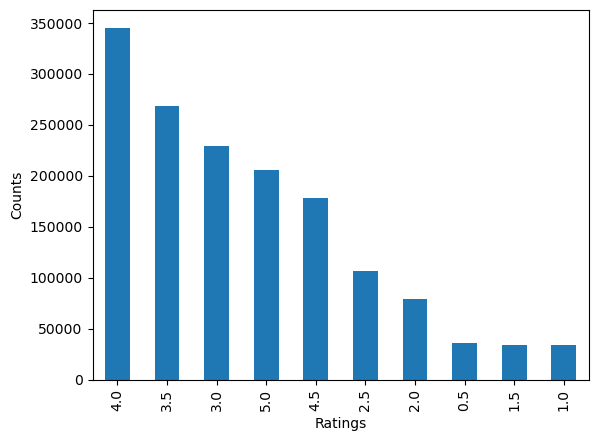

In [19]:
small_rating_df["rating"].value_counts().plot(kind='bar')
plt.xlabel("Ratings")
plt.ylabel("Counts")

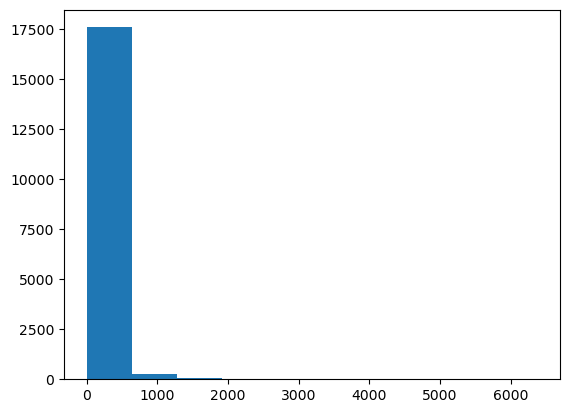

In [20]:
plt.hist(small_rating_df.groupby(by='userId')['rating'].count().values) 

plt.show()

In [ ]:
m  = sum(small_rating_df.groupby(by='userId')['rating'].count() < 10)
print(f"There are {m} users who wrote lesser than 5 reviews")

There are 3220 users who wrote lesser than 5 reviews


In [22]:
m  = sum(small_rating_df.groupby(by='movieId')['rating'].count() < 10)
print(f"There are {m} movies which got lesser than 5 reviews")

There are 37962 movies which got lesser than 5 reviews


### PREPARE TRAIN AND TEST DATASET - 10984 users and 36393 movies in training process

In [ ]:
small_rating_df = small_rating_df[small_rating_df['userId'].map(small_rating_df['userId'].value_counts()) > 10]
small_rating_df = small_rating_df[small_rating_df['movieId'].map(small_rating_df['movieId'].value_counts()) > 10]
print(f"There are total {small_rating_df['userId'].unique().shape[0]} unique users having more than 10 interactions")
print(f"There are total {small_rating_df['movieId'].unique().shape[0]} unique movies having more than 10 interactions")


There are total 12426 unique users having more than 10 interactions
There are total 9948 unique movies having more than 10 interactions


In [28]:
n = small_rating_df.shape[0]
n_train = int(n*0.5)

train_df = small_rating_df.iloc[:n_train]
test_df = small_rating_df.iloc[n_train: ]

In [29]:
print(train_df.shape)
print(test_df.shape)

(698113, 4)
(698113, 4)


In [30]:
unique_movies = set(train_df['movieId'].unique())
unique_users = set(train_df['userId'].unique())

In [31]:
print(f"Train Data: {(len(unique_users))} users and {len(unique_movies)} movies")

Train Data: 7964 users and 9725 movies


In [32]:
test_df = test_df[test_df['movieId'].isin(unique_movies)]
test_df = test_df[test_df['userId'].isin(unique_users)]

In [33]:
print(test_df.shape)

(141580, 4)


In [34]:
train_df.columns = ['userId', 'productId', 'rating', 'timestamp']
test_df.columns = ['userId', 'productId', 'rating', 'timestamp']

In [35]:
train_df.to_csv("data/movielens/train.csv")
test_df.to_csv("data/movielens/test.csv")

### TRAINING BY ALS METHOD

In [26]:
from MF_ALS.architecture import Encoder, ALSModelTrainer, ALSInference
import pandas as pd
import numpy as np
from numpy import unravel_index
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', None)

In [2]:
train_df = pd.read_csv("data/movielens/train.csv", index_col=0)
val_df = pd.read_csv("data/movielens/test.csv", index_col=0)

print(train_df.shape)
print(val_df.shape)

(698113, 4)
(141580, 4)


In [3]:
trainer = ALSModelTrainer(regulariser_1=5.0, regulariser_2=5.0, train_data=train_df, validation_data=val_df, dim=64)

At epoch - 0: max user diff norm: 1.8168958963063575 | max user bias diff : 2.412622216761585
At epoch - 0: max item diff norm: 6.382616818066852 | max item bias diff : 2.0508142787584953
At end of epoch 0| validation error: 0.7488305514829523 | train error: 0.6125723828579721

At epoch - 1: max user diff norm: 5.580845647457399 | max user bias diff : 0.49823755764743227
At epoch - 1: max item diff norm: 2.139521950299883 | max item bias diff : 0.4860521777151863
At end of epoch 1| validation error: 0.7359797283167872 | train error: 0.23877802162362283

At epoch - 2: max user diff norm: 1.142040417589788 | max user bias diff : 0.3976477983638187
At epoch - 2: max item diff norm: 0.7044614602152477 | max item bias diff : 0.204037884212802
At end of epoch 2| validation error: 0.7470974942221932 | train error: 0.1821920254279004

At epoch - 3: max user diff norm: 0.685598197068271 | max user bias diff : 0.20780890723196643
At epoch - 3: max item diff norm: 0.44120072429466656 | max item b

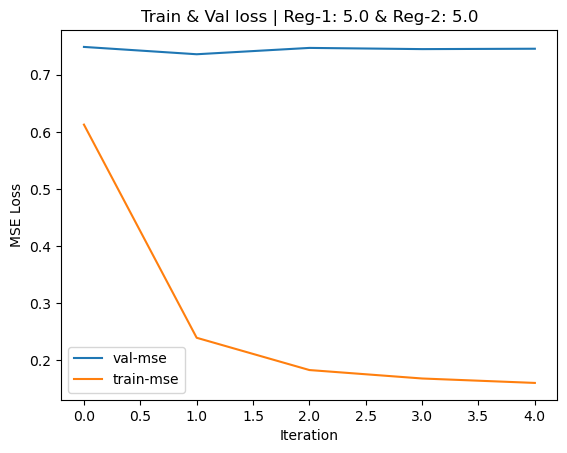

In [4]:
trainer.train(T=5)

### EXPLORING THE TRAINED LATENT DIMENSIONS

In [51]:
inference = ALSInference('epoch_4')
movies = pd.read_csv('data/movielens/movies.csv')
ratings = pd.read_csv('data/movielens/train.csv', index_col=0)

In [27]:
# MOST SIMILAR MOVIE PAIRS
movie_sim = inference.model.item_mat@inference.model.item_mat.T
np.fill_diagonal(movie_sim, -1)
max_pos = unravel_index(movie_sim.argmax(), movie_sim.shape)
movie_1, movie_2 = inference.enc.id_item[max_pos[0]], inference.enc.id_item[max_pos[1]]
print("Most similar movie pairs")
movies[movies['movieId'].isin([movie_1, movie_2])]

Most similar movie pairs


,movieId,title,genres
4888,4993,"Lord of the Rings: The Fellowship of the Ring, The (2001)",Adventure|Fantasy
7029,7153,"Lord of the Rings: The Return of the King, The (2003)",Action|Adventure|Drama|Fantasy


In [46]:
# Similar movie of any random movie
movie = inference.enc.id_item[260]
print(movies[movies['movieId'].isin([movie])])
movies[movies['movieId'].isin([movie])]
top_10 = movie_sim[260].argsort()[::-1][:10]
top_10 = [inference.enc.id_item[x] for x in top_10]
print('\nTop 10 similar movies of the above movie based on the viewing pattern')
movies[movies['movieId'].isin(top_10)]

      movieId                   title                  genres
1207     1240  Terminator, The (1984)  Action|Sci-Fi|Thriller

Top 10 similar movies of the above movie based on the viewing pattern


,movieId,title,genres
257,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
581,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi
1013,1036,Die Hard (1988),Action|Crime|Thriller
1166,1196,Star Wars: Episode V - The Empire Strikes Back (1980),Action|Adventure|Sci-Fi
1168,1198,Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981),Action|Adventure
1170,1200,Aliens (1986),Action|Adventure|Horror|Sci-Fi
1179,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
1183,1214,Alien (1979),Horror|Sci-Fi
1237,1270,Back to the Future (1985),Adventure|Comedy|Sci-Fi
2480,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller


In [61]:
# MOST SIMILAR USERS
user_sim = inference.model.user_mat@inference.model.user_mat.T
np.fill_diagonal(user_sim, -1)
max_pos = unravel_index(user_sim.argmax(), user_sim.shape)
user_1, user_2 = inference.enc.id_user[max_pos[0]], inference.enc.id_user[max_pos[1]]
user_1_movies = set(ratings[ratings['userId'] == user_1]['productId'])
user_2_movies = set(ratings[ratings['userId'] == user_2]['productId'])
print(f"User {user_1} wathced {len(user_1_movies)} movies")
print(f"User {user_2} wathced {len(user_2_movies)} movies")
print(f"Total {len(user_1_movies.intersection(user_2_movies))} movies common")


User 72231 wathced 751 movies
User 274536 wathced 1285 movies
Total 284 movies common


In [120]:
# RECOMMENDATION TO RANDOM USER
user = inference.enc.id_user[1048]
print(f"Top 10 rated movies by user {user} ")
df = ratings[ratings['userId'] == user].sort_values(by='rating', ascending=False)
df['movie'] = df['productId'].map(lambda x: movies[movies['movieId']==x]['title'].values[0])
df[['userId', 'movie', 'rating']].iloc[:10]

Top 10 rated movies by user 61485 


,userId,movie,rating
6303770,61485,The Bee Gees: How Can You Mend a Broken Heart (2020),4.0
6302397,61485,Mad Max (1979),4.0
6302398,61485,"Road Warrior, The (Mad Max 2) (1981)",4.0
6303526,61485,Trick 'r Treat (2007),4.0
6303777,61485,Spider-Man: No Way Home (2021),4.0
6301861,61485,Conan the Barbarian (1982),4.0
6303778,61485,The Batman (2022),4.0
6303779,61485,Scream (2022),4.0
6301803,61485,Dracula (Bram Stoker's Dracula) (1992),4.0
6302431,61485,Pumpkinhead (1988),4.0


In [121]:
rec, rating = inference.recommend(user, top_k=10)
print('Here are top 10 recommendations\n')
for i in rec:
    print(movies[movies['movieId']==i]['title'].values[0])

Here are top 10 recommendations

Band of Brothers (2001)
Planet Earth II (2016)
Parasite (2019)
O.J.: Made in America (2016)
Shawshank Redemption, The (1994)
Death Note: Desu nôto (2006–2007)
Planet Earth (2006)
Civil War, The (1990)
Come and See (Idi i smotri) (1985)
Cosmos: A Spacetime Odissey


In [133]:
# MOVIE HAVING HIGHEST BIAS
movie = np.argmax(inference.model.item_bias)
movie = inference.enc.id_item[movie]
avg = ratings[ratings['productId'] == movie]['rating'].mean()
print(f'Following movie has the highest bias, it has average rating {avg:0.1f}')
movies[movies['movieId']==movie]

Following movie has the highest bias, it has average rating 4.5


,movieId,title,genres
46156,170705,Band of Brothers (2001),Action|Drama|War


In [134]:
# MOVIE HAVING LOWEST BIAS
movie = np.argmin(inference.model.item_bias)
movie = inference.enc.id_item[movie]
avg = ratings[ratings['productId'] == movie]['rating'].mean()
print(f'Following movie has the highest bias, it has average rating {avg:0.1f}')
movies[movies['movieId']==movie]

Following movie has the highest bias, it has average rating 1.0


,movieId,title,genres
13213,67867,Dragonball Evolution (2009),Action|Adventure|Fantasy|Sci-Fi
